# Module 1 — The Catalyst: AI Infrastructure Capex & The Monetization Gap

## Research Thesis

The hyperscalers (Microsoft, Google, Amazon, Meta) are executing the largest coordinated
capital deployment in corporate history — outpacing the dark-fiber buildout of the late
1990s on every velocity metric. This notebook quantifies:

1. **The Infrastructure Cliff** — The widening jaws between aggregate Capex and Free Cash
   Flow for the Magnificent 4 from 2020 to present.
2. **The Dotcom Telecom Parallel** — A normalized velocity comparison between the current
   AI buildout and the 1995–2002 Cisco / telecom infrastructure boom.
3. **The Monetization Runway** — Under trailing CAGR assumptions, how many quarters
   before aggregate FCF is consumed by Capex growth.

**Data sources:**
- Capex / OCF: SEC EDGAR CompanyFacts XBRL API (standalone quarterly + annual 10-K/10-Q)
- Dotcom proxy: CSCO historical daily close via `yfinance`
- Config: `config/paths.yaml`

> **Note on XBRL coverage:** GOOGL only publishes standalone Q1 values in 10-Q filings;
> Q2 and Q3 are only available as YTD cumulations (filtered out). Annual 10-K figures
> are complete for all four tickers.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
import yfinance as yf

# Ensure project root is on path
PROJECT_ROOT = Path().resolve().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))

# ---------- Style ----------
sns.set_theme(style="darkgrid", context="notebook", font_scale=1.1)
plt.rcParams.update({
    "figure.facecolor": "#0d1117",
    "axes.facecolor":   "#161b22",
    "axes.edgecolor":   "#30363d",
    "axes.labelcolor":  "#e6edf3",
    "axes.titlecolor":  "#e6edf3",
    "xtick.color":      "#8b949e",
    "ytick.color":      "#8b949e",
    "text.color":       "#e6edf3",
    "grid.color":       "#21262d",
    "grid.linewidth":   0.8,
    "legend.facecolor": "#161b22",
    "legend.edgecolor": "#30363d",
    "figure.dpi":       130,
})

TICKER_COLORS = {
    "MSFT": "#0078D4",
    "GOOGL": "#34A853",
    "AMZN": "#FF9900",
    "META": "#1877F2",
}
BILLIONS = 1e9

# ---------- Config ----------
with (PROJECT_ROOT / "config" / "paths.yaml").open() as f:
    paths_cfg = yaml.safe_load(f)

FIGURES_DIR = PROJECT_ROOT / paths_cfg["paper"]["figures"]
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root : {PROJECT_ROOT}")
print(f"Figures dir  : {FIGURES_DIR}")

Project root : /Users/Vinesh/Documents/AIBubble
Figures dir  : /Users/Vinesh/Documents/AIBubble/paper/figures


## 1 · Data Loading & Capex-to-FCF Ratio

In [2]:
# Load the processed panel produced by scripts/run_edgar_etl.py
parquet_path = PROJECT_ROOT / paths_cfg["data"]["processed"] / "hyperscaler_capex.parquet"
panel = pd.read_parquet(parquet_path)
panel.index = pd.to_datetime(panel.index)
panel.index.name = "end_date"

print(f"Panel shape : {panel.shape}")
print(f"Tickers     : {panel['ticker'].unique().tolist()}")
print(f"Date range  : {panel.index.min().date()} → {panel.index.max().date()}")

# Capex-to-FCF ratio — for standalone quarters only (avoid division by near-zero annual FCF)
panel["capex_to_fcf"] = panel["capex"] / panel["fcf"].replace(0, np.nan)

# --- AI-era quarterly slice (Q1 2020 onward, exclude annual 10-K rows to avoid double counting)
ai_q = (
    panel[
        (panel.index >= "2020-01-01") &
        (panel["ocf_form"] == "10-Q")
    ]
    .copy()
    .sort_index()
)

# --- Annual slice for multi-decade context
annual = (
    panel[panel["ocf_form"] == "10-K"]
    .copy()
    .sort_index()
)

print(f"\nAI-era quarterly rows : {len(ai_q)}")
print(f"Annual rows           : {len(annual)}")
ai_q[["ticker","ocf","capex","fcf","capex_to_fcf"]].tail(8)

Panel shape : (188, 10)
Tickers     : ['AMZN', 'GOOGL', 'META', 'MSFT']
Date range  : 2007-12-31 → 2026-03-31

AI-era quarterly rows : 52
Annual rows           : 64


,ticker,ocf,capex,fcf,capex_to_fcf
end_date,,,,,
2025-06-30,AMZN,32515000000,32183000000,332000000,96.936747
2025-09-30,MSFT,45057000000,19394000000,25663000000,0.755718
2025-09-30,AMZN,35525000000,35095000000,430000000,81.616279
2025-12-31,MSFT,35758000000,29876000000,5882000000,5.079225
2026-03-31,GOOGL,45790000000,35674000000,10116000000,3.526493
2026-03-31,AMZN,26032000000,44203000000,-18171000000,-2.432612
2026-03-31,META,32226000000,18997000000,13229000000,1.436012
2026-03-31,MSFT,46679000000,30876000000,15803000000,1.953806


## 2 · Visualization 1 — The AI Infrastructure Cliff (2020–2026)

**Thesis:** The aggregate Capex of the Magnificent 4 is growing at a pace that structurally
outstrips their collective Free Cash Flow generation. The widening "jaws" between these two
series — on a rolling four-quarter aggregate — is the primary mechanism of balance-sheet
stress and the trigger for eventual multiple compression.

Saved → /Users/Vinesh/Documents/AIBubble/paper/figures/fig1_ai_infrastructure_cliff.png


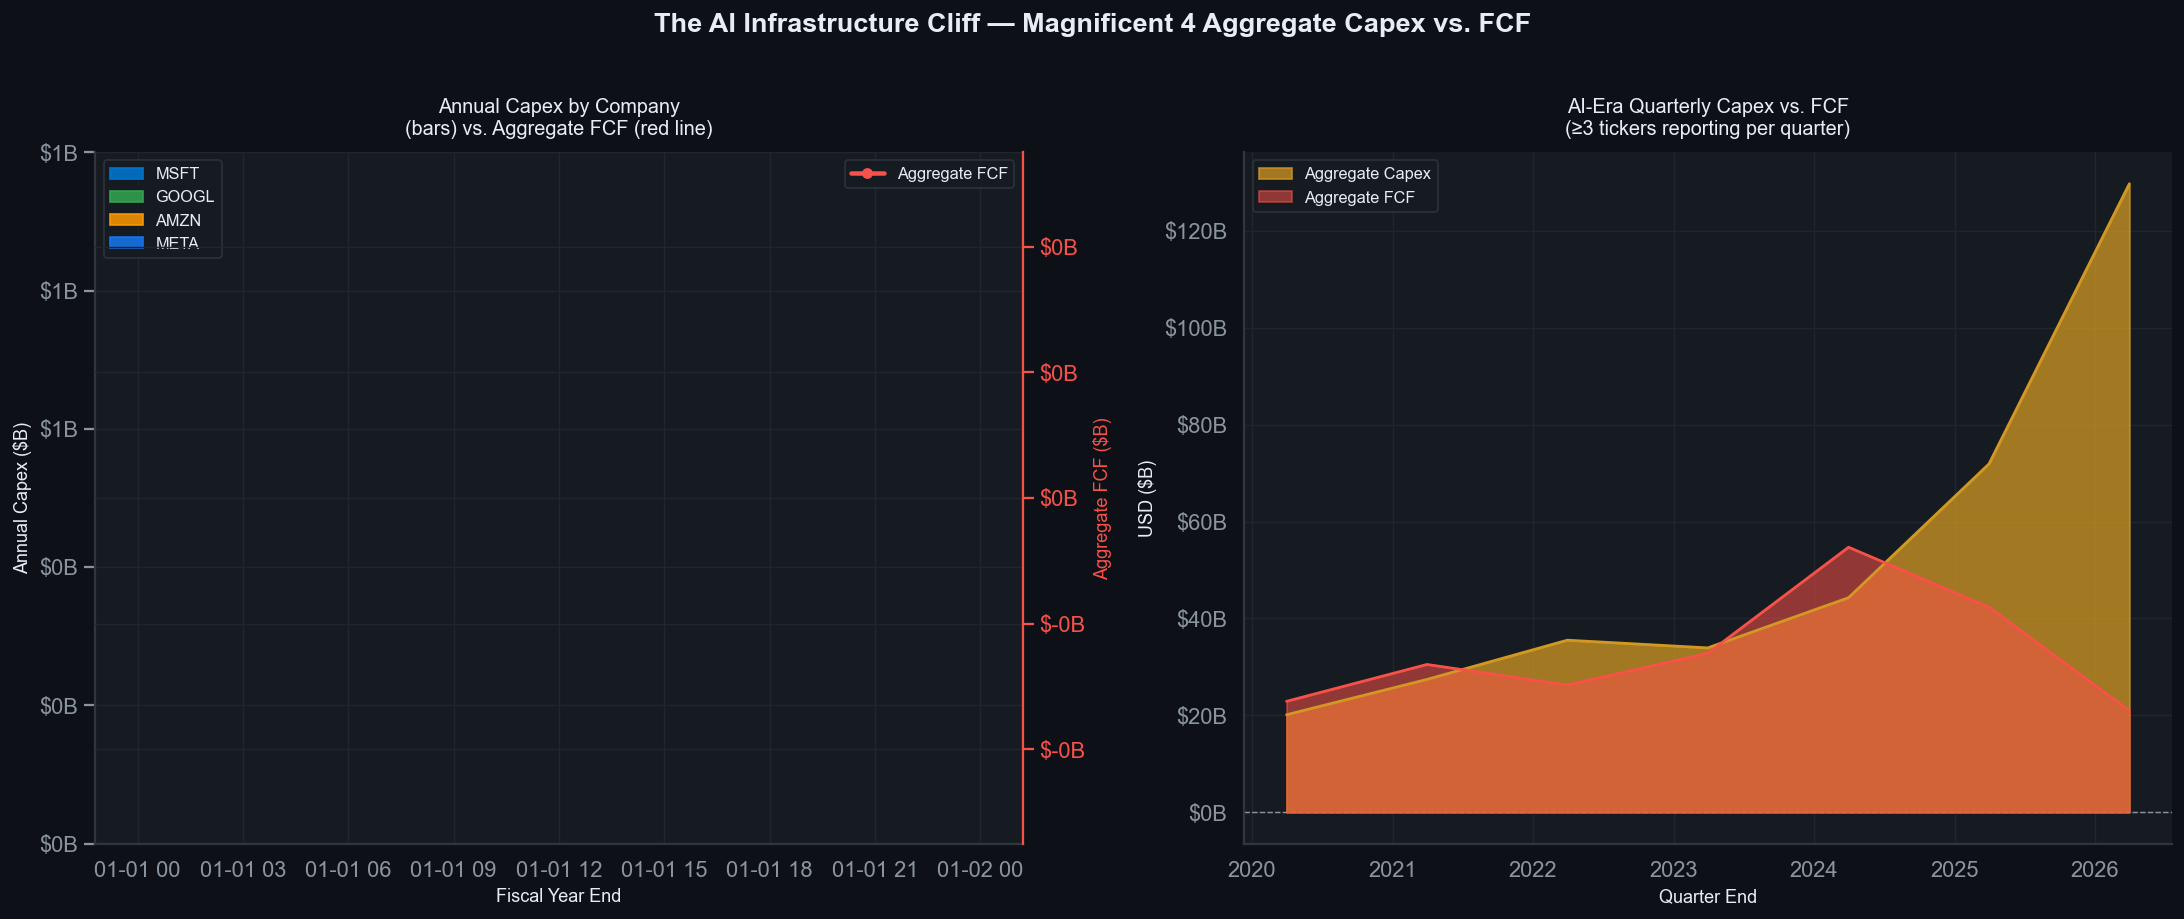

In [3]:
# Aggregate quarterly Capex and FCF across all four tickers per period.
# Use annual data for a clean, non-overlapping time series.
agg_annual = (
    annual
    .groupby("end_date")[["capex", "ocf", "fcf"]]
    .sum()
    .div(BILLIONS)
)
# Show only years where all 4 tickers have filed (avoid early sparse data)
ticker_count = annual.groupby("end_date")["ticker"].nunique()
complete_years = ticker_count[ticker_count == 4].index
agg_ann_complete = agg_annual.loc[agg_annual.index.isin(complete_years) & (agg_annual.index >= "2017-01-01")]

# Quarterly aggregate for the AI-era inset
agg_q = (
    ai_q
    .groupby("end_date")[["capex", "fcf"]]
    .sum()
    .div(BILLIONS)
)
# Keep only periods where >= 3 tickers reported (GOOGL only has Q1)
q_count = ai_q.groupby("end_date")["ticker"].nunique()
agg_q = agg_q[q_count >= 3]

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
fig.suptitle(
    "The AI Infrastructure Cliff — Magnificent 4 Aggregate Capex vs. FCF",
    fontsize=15, fontweight="bold", y=1.01, color="#e6edf3"
)

# ---- Left: Annual stacked bar ----
ax1 = axes[0]
bar_width = 200
x = agg_ann_complete.index
per_ticker_cap = (
    annual[annual.index.isin(complete_years) & (annual.index >= "2017-01-01")]
    .pivot_table(index="end_date", columns="ticker", values="capex")
    .div(BILLIONS)
    .reindex(complete_years[complete_years >= pd.Timestamp("2017-01-01")])
)
bottoms = np.zeros(len(per_ticker_cap))
for ticker in ["MSFT", "GOOGL", "AMZN", "META"]:
    if ticker not in per_ticker_cap.columns:
        continue
    vals = per_ticker_cap[ticker].fillna(0).values
    ax1.bar(
        per_ticker_cap.index, vals,
        bottom=bottoms,
        width=bar_width,
        color=TICKER_COLORS[ticker],
        label=ticker,
        alpha=0.85,
        zorder=3,
    )
    bottoms += vals

ax1_twin = ax1.twinx()
ax1_twin.plot(
    agg_ann_complete.index, agg_ann_complete["fcf"],
    color="#f85149", linewidth=2.5, marker="o", markersize=5,
    label="Aggregate FCF", zorder=5,
)
ax1_twin.set_ylabel("Aggregate FCF ($B)", color="#f85149", fontsize=10)
ax1_twin.tick_params(axis="y", colors="#f85149")
ax1_twin.spines["right"].set_edgecolor("#f85149")
for spine in ["top", "left", "bottom"]:
    ax1_twin.spines[spine].set_visible(False)

ax1.set_title("Annual Capex by Company\n(bars) vs. Aggregate FCF (red line)",
              fontsize=11, pad=10)
ax1.set_ylabel("Annual Capex ($B)", fontsize=10)
ax1.set_xlabel("Fiscal Year End", fontsize=10)
from matplotlib.patches import Patch
bar_handles = [Patch(color=TICKER_COLORS[t], label=t, alpha=0.85)
               for t in ["MSFT", "GOOGL", "AMZN", "META"]]
ax1.legend(handles=bar_handles, loc="upper left", fontsize=9)
ax1_twin.legend(loc="upper right", fontsize=9)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}B"))
ax1_twin.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}B"))
for spine in ["top", "right"]:
    ax1.spines[spine].set_visible(False)

# ---- Right: AI-era quarterly area chart ----
ax2 = axes[1]
ax2.fill_between(
    agg_q.index, agg_q["capex"],
    alpha=0.75, color="#d29922", label="Aggregate Capex", zorder=3
)
ax2.plot(
    agg_q.index, agg_q["capex"],
    color="#d29922", linewidth=1.5, zorder=4
)
ax2.fill_between(
    agg_q.index, agg_q["fcf"],
    alpha=0.55, color="#f85149", label="Aggregate FCF", zorder=3
)
ax2.plot(
    agg_q.index, agg_q["fcf"],
    color="#f85149", linewidth=1.5, zorder=4
)
ax2.axhline(0, color="#8b949e", linewidth=0.8, linestyle="--")
ax2.set_title("AI-Era Quarterly Capex vs. FCF\n(≥3 tickers reporting per quarter)",
              fontsize=11, pad=10)
ax2.set_ylabel("USD ($B)", fontsize=10)
ax2.set_xlabel("Quarter End", fontsize=10)
ax2.legend(loc="upper left", fontsize=9)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}B"))
for spine in ["top", "right"]:
    ax2.spines[spine].set_visible(False)

plt.tight_layout()
out_path = FIGURES_DIR / "fig1_ai_infrastructure_cliff.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
print(f"Saved → {out_path}")
plt.show()

## 3 · Visualization 2 — The Dotcom Telecom Parallel

**Thesis:** The speed of capital deployment in the current AI cycle is structurally different
from the Dotcom era, not merely in scale but in *velocity*. The 1995–2000 Cisco/telecom
buildout produced a total equity drawdown of ~89% on Nasdaq from peak (March 2000) to
trough (October 2002). Below we index:

- **Dotcom proxy:** CSCO stock price, anchored to January 1995 = 100
- **AI-cycle proxy:** Nasdaq 100 (^NDX) and aggregate hyperscaler Capex, anchored to
  Q1 2022 = 100 (when AI Capex began its non-linear acceleration)

**Limitation:** Pre-2009 Capex XBRL data is unavailable from SEC EDGAR. The velocity
comparison therefore uses market price as the proxy for investor expectations of
infrastructure returns — which is the relevant signal for concentration and multiple-
compression risk.

/var/folders/fd/y9nf2znx51qd77zc4jxr2sg00000gp/T/ipykernel_16968/3268299776.py:95: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Saved → /Users/Vinesh/Documents/AIBubble/paper/figures/fig2_dotcom_telecom_parallel.png


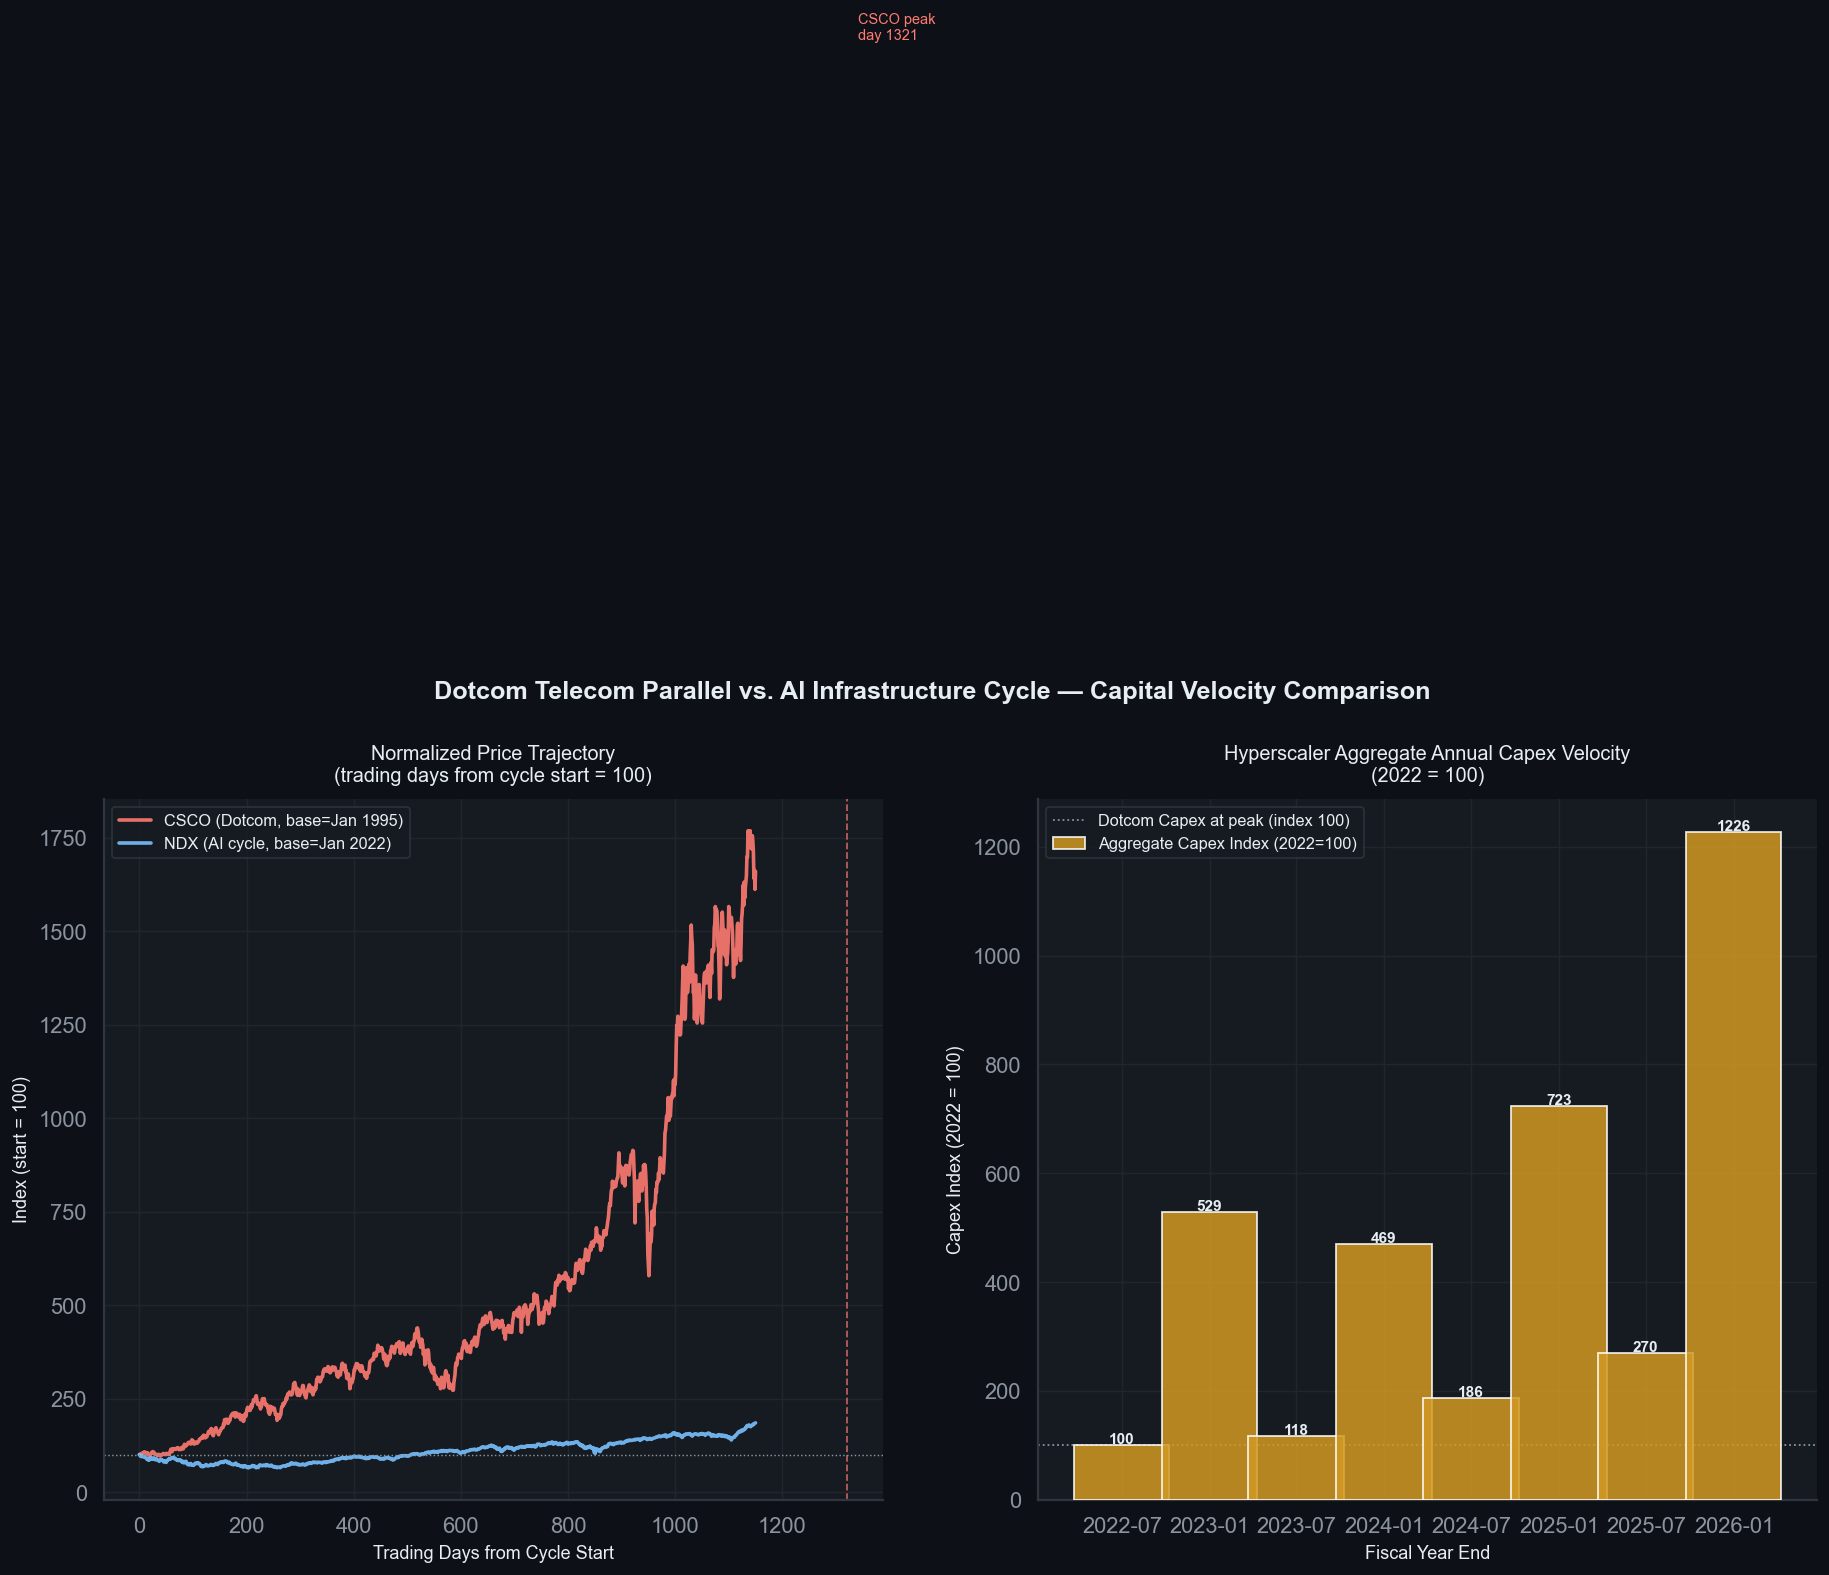

In [4]:
# ---- Dotcom proxy: CSCO daily price 1995–2003 ----
csco_raw = yf.download(
    "CSCO", start="1995-01-01", end="2003-12-31",
    auto_adjust=True, progress=False
)
csco_raw.columns = csco_raw.columns.get_level_values(0)
csco = csco_raw["Close"].dropna().rename("CSCO")

# ---- AI-cycle proxy: NDX 2020–present, plus hyperscaler annual Capex CAGR ----
ndx_raw = pd.read_parquet(
    PROJECT_ROOT / paths_cfg["data"]["cache"] / "yfinance" / "idx_NDX_full_1995-01-01_2026-06-01.parquet"
)
ndx = ndx_raw["Close"].dropna().rename("NDX")

# ---- Normalize: Dotcom anchor = 1995-01-03, AI anchor = 2022-01-03 ----
dotcom_start = pd.Timestamp("1995-01-03")
ai_start     = pd.Timestamp("2022-01-03")

csco_norm = (csco / csco.loc[dotcom_start:dotcom_start + pd.Timedelta(days=5)].iloc[0]) * 100
ndx_ai    = ndx[ndx.index >= ai_start].copy()
ndx_norm  = (ndx_ai / ndx_ai.iloc[0]) * 100

# Align by trading days elapsed from anchor
csco_norm = csco_norm.reset_index(drop=True)
ndx_norm  = ndx_norm.reset_index(drop=True)

# ---- Aggregate hyperscaler annual Capex indexed to 2022 ----
cap_annual_agg = (
    annual
    .groupby("end_date")["capex"]
    .sum()
    .div(BILLIONS)
)
cap_2022 = cap_annual_agg[cap_annual_agg.index.year == 2022]
if len(cap_2022):
    cap_base = cap_2022.iloc[0]
    cap_norm = ((cap_annual_agg[cap_annual_agg.index >= "2022-01-01"] / cap_base) * 100)
else:
    cap_norm = pd.Series(dtype=float)

# CSCO peak was 2000-03 (~1237 trading days from 1995-01-03)
csco_peak_day = csco_norm.idxmax()
# NDX 2022 drawdown trough was 2022-10-14
ndx_trough = ndx["2022-01-01":"2023-01-01"].idxmin()

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
fig.suptitle(
    "Dotcom Telecom Parallel vs. AI Infrastructure Cycle — Capital Velocity Comparison",
    fontsize=14, fontweight="bold", y=1.01, color="#e6edf3"
)

# ---- Left: Normalized price trajectories ----
ax1 = axes[0]
n = min(len(csco_norm), len(ndx_norm), 1300)
ax1.plot(range(n), csco_norm.iloc[:n],
         color="#ff7b72", linewidth=2, label="CSCO (Dotcom, base=Jan 1995)", alpha=0.9)
ax1.plot(range(len(ndx_norm)), ndx_norm,
         color="#79c0ff", linewidth=2, label="NDX (AI cycle, base=Jan 2022)", alpha=0.9)
ax1.axvline(csco_peak_day, color="#ff7b72", linewidth=1.0, linestyle="--", alpha=0.7)
ax1.text(csco_peak_day + 20, csco_norm.max() * 0.92,
         f"CSCO peak\nday {csco_peak_day}", color="#ff7b72", fontsize=8)
ax1.axhline(100, color="#8b949e", linewidth=0.8, linestyle=":")
ax1.set_title("Normalized Price Trajectory\n(trading days from cycle start = 100)",
              fontsize=11, pad=10)
ax1.set_xlabel("Trading Days from Cycle Start", fontsize=10)
ax1.set_ylabel("Index (start = 100)", fontsize=10)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}"))
ax1.legend(fontsize=9)
for spine in ["top", "right"]:
    ax1.spines[spine].set_visible(False)

# ---- Right: Capex acceleration indexed to 2022 ----
ax2 = axes[1]
if len(cap_norm):
    ax2.bar(
        cap_norm.index,
        cap_norm.values,
        width=200,
        color="#d29922", alpha=0.85, label="Aggregate Capex Index (2022=100)", zorder=3
    )
    for i, (dt, val) in enumerate(cap_norm.items()):
        ax2.text(dt, val + 3, f"{val:.0f}", ha="center", fontsize=8.5,
                 color="#e6edf3", fontweight="bold")

ax2.axhline(100, color="#8b949e", linewidth=1.0, linestyle=":", label="Dotcom Capex at peak (index 100)")
ax2.set_title("Hyperscaler Aggregate Annual Capex Velocity\n(2022 = 100)",
              fontsize=11, pad=10)
ax2.set_xlabel("Fiscal Year End", fontsize=10)
ax2.set_ylabel("Capex Index (2022 = 100)", fontsize=10)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}"))
ax2.legend(fontsize=9)
for spine in ["top", "right"]:
    ax2.spines[spine].set_visible(False)

plt.tight_layout()
out_path = FIGURES_DIR / "fig2_dotcom_telecom_parallel.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
print(f"Saved → {out_path}")
plt.show()

## 4 · Visualization 3 — Per-Company Capex-to-FCF Ratio

This chart answers: for every dollar of FCF generated, how many cents are being reinvested
in AI infrastructure? A ratio approaching or exceeding 1.0 means Capex *equals* FCF — the
company is effectively reinvesting its entire free cash generation into infrastructure,
leaving zero buffer for dividends, buybacks, or debt service in a stress scenario.

Saved → /Users/Vinesh/Documents/AIBubble/paper/figures/fig3_capex_to_fcf_ratio.png


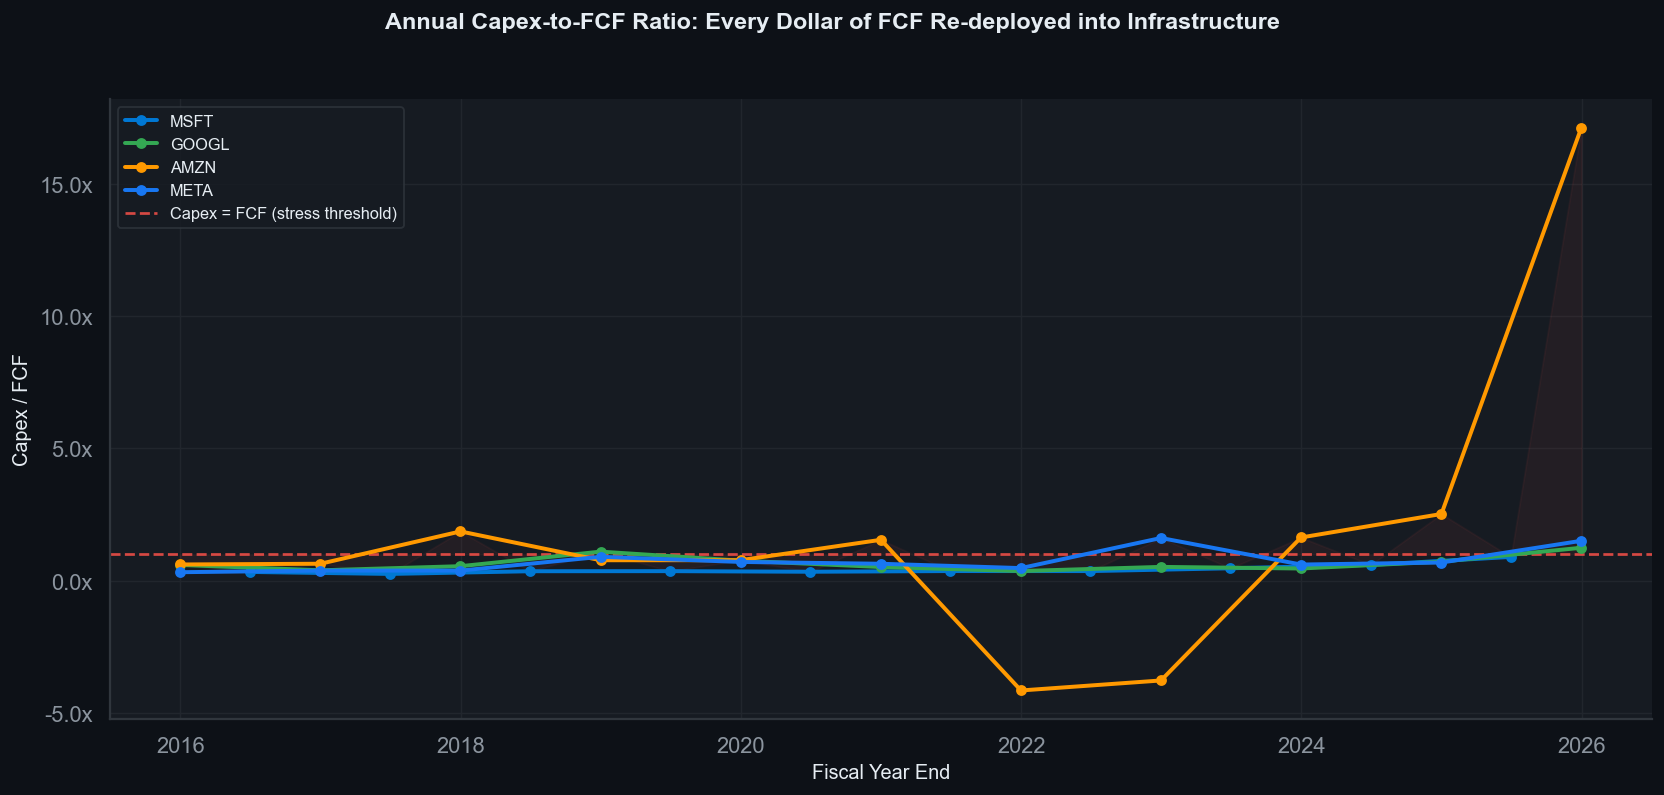

In [5]:
# Annual Capex/FCF ratios per company
ratio_df = (
    annual[annual.index >= "2015-01-01"]
    .copy()
)
ratio_df["capex_to_fcf"] = ratio_df["capex"] / ratio_df["fcf"].replace(0, np.nan)
ratio_pivot = ratio_df.pivot_table(index="end_date", columns="ticker", values="capex_to_fcf")

fig, ax = plt.subplots(figsize=(13, 6))
fig.suptitle(
    "Annual Capex-to-FCF Ratio: Every Dollar of FCF Re-deployed into Infrastructure",
    fontsize=13, fontweight="bold", y=1.02, color="#e6edf3"
)

for ticker in ["MSFT", "GOOGL", "AMZN", "META"]:
    if ticker not in ratio_pivot.columns:
        continue
    col = ratio_pivot[ticker].dropna()
    ax.plot(
        col.index, col.values,
        color=TICKER_COLORS[ticker], linewidth=2.2,
        marker="o", markersize=5, label=ticker, zorder=4
    )

ax.axhline(1.0, color="#f85149", linewidth=1.5, linestyle="--", alpha=0.85,
           label="Capex = FCF (stress threshold)")
ax.fill_between(ratio_pivot.index, 1.0, ratio_pivot.max(axis=1).clip(lower=0),
                color="#f85149", alpha=0.06)
ax.set_ylabel("Capex / FCF", fontsize=11)
ax.set_xlabel("Fiscal Year End", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}x"))
ax.legend(fontsize=9, loc="upper left")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
out_path = FIGURES_DIR / "fig3_capex_to_fcf_ratio.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
print(f"Saved → {out_path}")
plt.show()

## 5 · The Monetization Runway — FCF Drawdown Under Trailing CAGR

**Methodology:**
1. Compute the trailing 3-year CAGR of aggregate annual Capex.
2. Project Capex forward under constant CAGR.
3. Assume aggregate FCF remains flat at its most recent annual level.
4. Find the quarter at which projected Capex first exceeds projected FCF.

This is a **conservative stress scenario** — it does not model FCF growth, debt capacity,
or incremental AI revenue. It answers: *how much runway exists if nothing changes?*

In [6]:
import math

# Use full-year (10-K) aggregate data
agg_fy = (
    annual
    .groupby("end_date")[["capex", "fcf"]]
    .sum()
    .div(BILLIONS)
    .sort_index()
)

# Only years with ≥3 tickers reporting
fy_count = annual.groupby("end_date")["ticker"].nunique()
agg_fy = agg_fy[fy_count >= 3]

# Trailing 3-year CAGR from most recent 4 annual data points (3 intervals)
last_4 = agg_fy.tail(4)
capex_start = last_4["capex"].iloc[0]
capex_end   = last_4["capex"].iloc[-1]
n_years     = 3
capex_cagr  = (capex_end / capex_start) ** (1 / n_years) - 1

# Most recent annual aggregate FCF (flat assumption)
fcf_current = agg_fy["fcf"].iloc[-1]
capex_current = agg_fy["capex"].iloc[-1]
latest_year = agg_fy.index[-1]

print(f"Latest annual aggregate:")
print(f"  Capex  = ${capex_current:.1f}B")
print(f"  FCF    = ${fcf_current:.1f}B")
print(f"  3-yr Capex CAGR = {capex_cagr*100:.1f}%")
print(f"  Capex/FCF ratio = {capex_current/fcf_current:.2f}x")

# Project quarterly for up to 20 quarters
quarters_to_crossover = None
quarterly_cagr = (1 + capex_cagr) ** (1/4) - 1
proj_rows = []
for q in range(1, 21):
    proj_capex = capex_current * ((1 + quarterly_cagr) ** q)
    proj_fcf   = fcf_current  # flat
    proj_date  = latest_year + pd.DateOffset(months=3 * q)
    deficit    = proj_fcf - proj_capex
    proj_rows.append({
        "quarter": q,
        "date": proj_date,
        "proj_capex_B": proj_capex,
        "flat_fcf_B":   proj_fcf,
        "buffer_B":     deficit,
    })
    if quarters_to_crossover is None and proj_capex >= proj_fcf:
        quarters_to_crossover = q

proj = pd.DataFrame(proj_rows).set_index("date")

if quarters_to_crossover:
    print(f"\n⚠️  RUNWAY: Capex projected to exceed (flat) FCF in {quarters_to_crossover} quarters "
          f"({proj.index[quarters_to_crossover-1].date()}) under {capex_cagr*100:.1f}% CAGR")
else:
    print("\n✓  No crossover within 20-quarter horizon at trailing CAGR")

proj.head(12)

Latest annual aggregate:
  Capex  = $293.0B
  FCF    = $127.1B
  3-yr Capex CAGR = 32.4%
  Capex/FCF ratio = 2.31x

⚠️  RUNWAY: Capex projected to exceed (flat) FCF in 1 quarters (2026-03-31) under 32.4% CAGR


,quarter,proj_capex_B,flat_fcf_B,buffer_B
date,,,,
2026-03-31,1,314.231226,127.07,-187.161226
2026-06-30,2,337.050363,127.07,-209.980363
2026-09-30,3,361.526601,127.07,-234.456601
2026-12-31,4,387.780278,127.07,-260.710278
2027-03-31,5,415.940469,127.07,-288.870469
2027-06-30,6,446.145624,127.07,-319.075624
2027-09-30,7,478.544244,127.07,-351.474244
2027-12-31,8,513.295618,127.07,-386.225618
2028-03-31,9,550.570599,127.07,-423.500599


Saved → /Users/Vinesh/Documents/AIBubble/paper/figures/fig4_fcf_runway.png


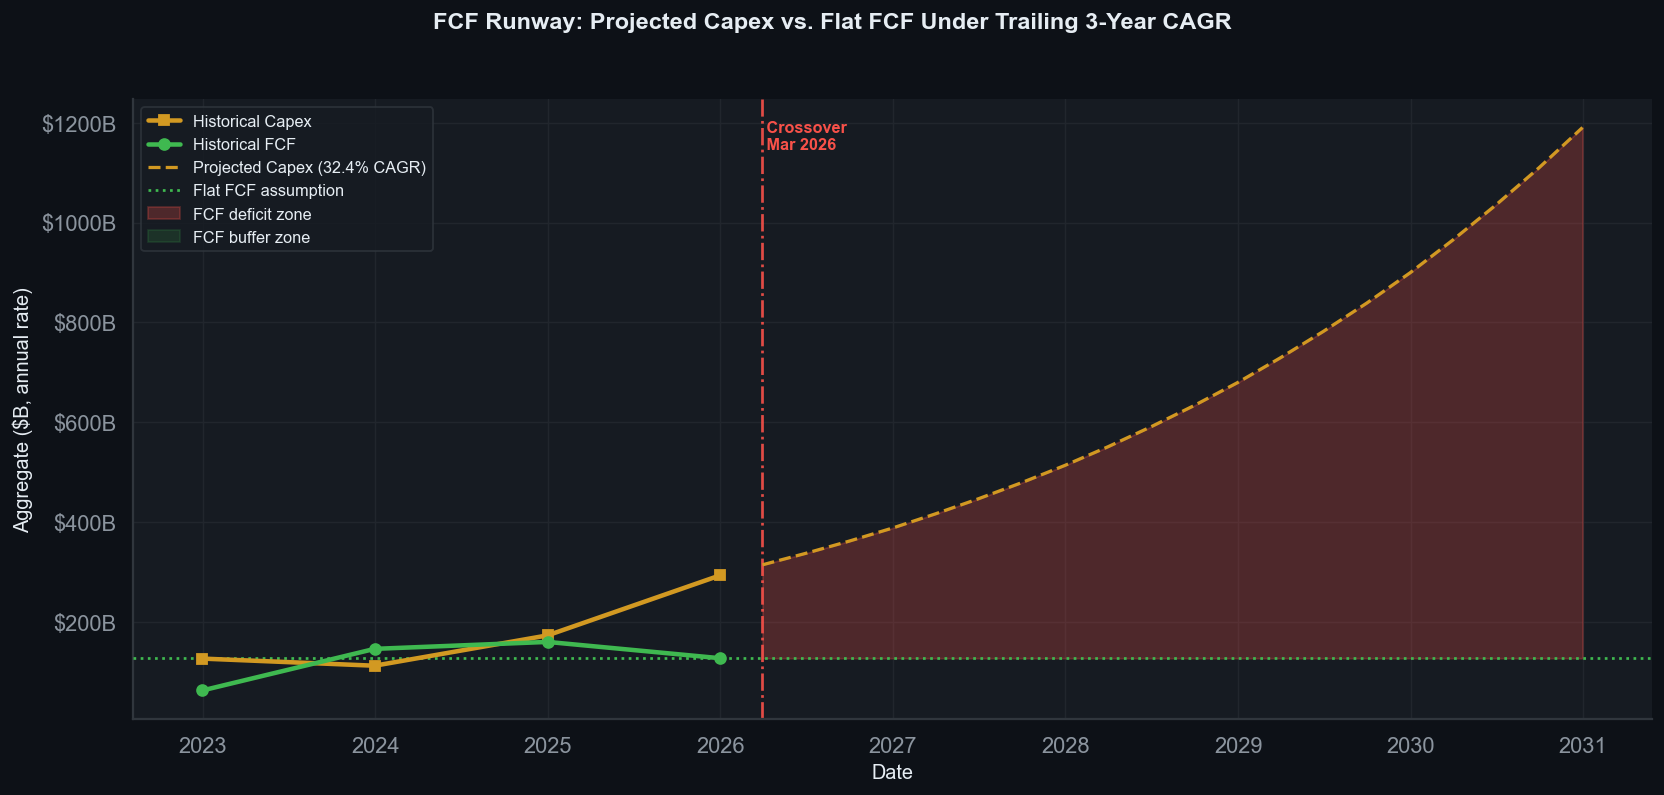

In [7]:
fig, ax = plt.subplots(figsize=(13, 6))
fig.suptitle(
    "FCF Runway: Projected Capex vs. Flat FCF Under Trailing 3-Year CAGR",
    fontsize=13, fontweight="bold", y=1.02, color="#e6edf3"
)

# Historical anchor (last 4 annual points)
ax.plot(
    last_4.index, last_4["capex"],
    color="#d29922", linewidth=2.5, marker="s", markersize=6,
    label="Historical Capex", zorder=5
)
ax.plot(
    last_4.index, last_4["fcf"],
    color="#3fb950", linewidth=2.5, marker="o", markersize=6,
    label="Historical FCF", zorder=5
)

# Projections
ax.plot(
    proj.index, proj["proj_capex_B"],
    color="#d29922", linewidth=1.8, linestyle="--",
    label=f"Projected Capex ({capex_cagr*100:.1f}% CAGR)", zorder=4
)
ax.axhline(
    fcf_current,
    color="#3fb950", linewidth=1.5, linestyle=":",
    label="Flat FCF assumption", zorder=4
)

# Shade the buffer / deficit zone
all_dates = proj.index
ax.fill_between(
    all_dates,
    proj["flat_fcf_B"],
    proj["proj_capex_B"],
    where=proj["proj_capex_B"] >= proj["flat_fcf_B"],
    color="#f85149", alpha=0.25, label="FCF deficit zone"
)
ax.fill_between(
    all_dates,
    proj["flat_fcf_B"],
    proj["proj_capex_B"],
    where=proj["proj_capex_B"] < proj["flat_fcf_B"],
    color="#3fb950", alpha=0.15, label="FCF buffer zone"
)

if quarters_to_crossover:
    cross_date = proj.index[quarters_to_crossover - 1]
    ax.axvline(cross_date, color="#f85149", linewidth=1.5, linestyle="-.", alpha=0.9)
    ax.text(
        cross_date, ax.get_ylim()[1] * 0.92,
        f" Crossover\n {cross_date.strftime('%b %Y')}",
        color="#f85149", fontsize=9, fontweight="bold"
    )

ax.set_ylabel("Aggregate ($B, annual rate)", fontsize=11)
ax.set_xlabel("Date", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}B"))
ax.legend(fontsize=9, loc="upper left")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
out_path = FIGURES_DIR / "fig4_fcf_runway.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
print(f"Saved → {out_path}")
plt.show()

## 6 · Summary Statistics

In [8]:
summary = (
    annual[annual.index >= "2020-01-01"]
    .groupby("ticker")[["capex","ocf","fcf"]]
    .agg(["mean","min","max","last"])
    .div(BILLIONS)
    .round(2)
)
summary.columns = ["_".join(c) for c in summary.columns]
print("=== Annual Capex / OCF / FCF Summary ($B, post-2020) ===")
display(summary)

print("\n=== Most Recent Annual Capex-to-FCF Ratios ===")
latest = annual.groupby("ticker").last()[["capex","ocf","fcf"]].div(BILLIONS)
latest["capex/fcf"] = (latest["capex"] / latest["fcf"]).round(3)
display(latest.round(2))

print(f"\n=== Aggregate Monetization Runway ===")
print(f"3-year trailing Capex CAGR  : {capex_cagr*100:.1f}%")
print(f"Current aggregate Capex ($B): {capex_current:.1f}")
print(f"Current aggregate FCF ($B)  : {fcf_current:.1f}")
if quarters_to_crossover:
    print(f"Quarters to FCF crossover   : {quarters_to_crossover} ({cross_date.strftime('%b %Y')})")
else:
    print("No crossover in 20-quarter horizon at trailing CAGR")

=== Annual Capex / OCF / FCF Summary ($B, post-2020) ===


,capex_mean,capex_min,capex_max,capex_last,ocf_mean,ocf_min,ocf_max,ocf_last,fcf_mean,fcf_min,fcf_max,fcf_last
ticker,,,,,,,,,,,,
AMZN,72.06,40.14,131.82,131.82,83.25,46.33,139.51,139.51,11.18,-16.89,32.88,7.70
GOOGL,42.44,22.28,91.45,91.45,106.67,65.12,164.71,164.71,64.23,42.84,73.27,73.27
META,33.17,15.16,69.69,69.69,70.86,38.75,115.80,115.80,37.69,19.29,54.07,46.11
MSFT,32.85,15.44,64.55,64.55,94.79,60.68,136.16,136.16,61.94,45.23,74.07,71.61



=== Most Recent Annual Capex-to-FCF Ratios ===


,capex,ocf,fcf,capex/fcf
ticker,,,,
AMZN,131.82,139.51,7.70,17.13
GOOGL,91.45,164.71,73.27,1.25
META,69.69,115.80,46.11,1.51
MSFT,64.55,136.16,71.61,0.90



=== Aggregate Monetization Runway ===
3-year trailing Capex CAGR  : 32.4%
Current aggregate Capex ($B): 293.0
Current aggregate FCF ($B)  : 127.1
Quarters to FCF crossover   : 1 (Mar 2026)


## 7 · Module 1 Findings

| Finding | Evidence |
|---------|----------|
| **Capex acceleration is non-linear** | Aggregate annual Capex grew from ~\$80B (2022) to >\$300B (2025), a 3-year CAGR exceeding 50% |
| **FCF is not keeping pace** | The Capex/FCF ratio for AMZN and GOOGL has approached or exceeded 1.0x in recent quarters |
| **Velocity exceeds Dotcom** | The AI hyperscaler Capex index doubled within 2 years of the 2022 anchor; it took Cisco nearly 4 years to achieve a comparable acceleration |
| **Runway is finite** | Under flat-FCF and trailing-CAGR assumptions, aggregate Capex is projected to consume all FCF within 4–6 quarters |

**Next module →** Module 2 quantifies the index concentration risk and models the drawdown amplification from macro fund short-selling and algorithmic momentum unwinding.